# Notebook 4 — Bayesian Online Learning & Posterior Predictive

| Trường | Nội dung |
|---|---|
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 4 of 7 |
| **Input** | `data/processed/sp500_features.csv` · `models/scaler.pkl` |
| **Output** | `data/processed/validation_predictions.csv` · `models/posterior_final.pkl` · figures `reports/figures/nb4/` |
| **Trọng tâm** | Prior Initialization · Laplace Approximation · Bayesian Online Update · Posterior Predictive |

## 0. Import & Cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9
})

FIGURES_DIR = '../reports/figures/nb4'
MODELS_DIR  = '../models'
PROCESSED_DIR = '../data/processed'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('✓ Imports OK')

✓ Imports OK


## 1. Load dữ liệu & Chronological Split

In [2]:
FEATURE_COLS = [
    'Return', 'Volatility', 'MA_Ratio', 'Lag1', 'Lag2',
    'Intraday_Range', 'Close_Position',
    'Volume_Ratio', 'Volatility_Ratio'
]
TARGET = 'Label'

# ✅ FIX: dùng index_col=0 + parse_dates=True để giữ DatetimeIndex
# Tránh dùng parse_dates=['Date'] + reset_index() sẽ làm mất Date thành int
df = pd.read_csv(f'{PROCESSED_DIR}/sp500_features.csv', index_col=0, parse_dates=True)
df = df.sort_index()

missing = [c for c in FEATURE_COLS + [TARGET] if c not in df.columns]
if missing:
    raise ValueError(f'Cột không tìm thấy: {missing}')

n         = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

# Load scaler đã fit từ NB3
try:
    scaler = joblib.load(f'{MODELS_DIR}/scaler.pkl')
    print('✓ Loaded scaler từ NB3')
except FileNotFoundError:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaler.fit(train_df[FEATURE_COLS].values)
    print('⚠ scaler.pkl không tìm thấy — fit lại trên train set')

X_train = scaler.transform(train_df[FEATURE_COLS].values)
X_val   = scaler.transform(val_df[FEATURE_COLS].values)
X_test  = scaler.transform(test_df[FEATURE_COLS].values)

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

# DatetimeIndex → dùng trực tiếp, không cần .values để giữ ngày
val_dates  = val_df.index
test_dates = test_df.index

prior_prob_pos = y_train.mean()

print(f'Train  : {len(train_df)} rows | {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val    : {len(val_df)} rows   | {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test   : {len(test_df)} rows  | {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'p(y=1) train: {prior_prob_pos:.4f}')

✓ Loaded scaler từ NB3
Train  : 1432 rows | 2015-07-07 → 2021-03-12
Val    : 477 rows   | 2021-03-15 → 2023-02-02
Test   : 478 rows  | 2023-02-03 → 2024-12-27
p(y=1) train: 0.1997


## 2. Phase 1 — Prior Initialization

Trước khi thấy bất kỳ dữ liệu nào, ta cần thiết lập **prior distribution** $p(\theta)$ — niềm tin ban đầu về tham số mô hình.

$$\theta \sim \mathcal{N}(\mu_0, \Sigma_0)$$

### Chọn prior như thế nào?

**Intercept** $\theta_0$: thay vì chọn $\mu_0 = 0$ (không biết gì), ta dùng thông tin class balance từ training set:

$$\mu_{\text{intercept}} = \log\left(\frac{p(y=1)}{p(y=0)}\right) = \text{log-odds}$$

Ý nghĩa: nếu tập train có 20% positive, log-odds = $\log(0.2/0.8) \approx -1.39$ — mô hình bắt đầu với xu hướng dự đoán negative, phù hợp với class imbalance.

**Feature coefficients** $\theta_1, \ldots, \theta_d$: zero-centered ($\mu_j = 0$) — không thiên vị về dấu của bất kỳ feature nào.

**Prior variance** $\sigma^2 = 1.0$:
- Lớn hơn → prior yếu hơn (vague/uninformative), dữ liệu chiếm ưu thế.
- Nhỏ hơn → prior mạnh hơn (regularization mạnh), giữ tham số gần 0.
- $\sigma^2 = 1.0$ là lựa chọn conservative phù hợp với tài chính (low signal-to-noise).

**Prior covariance** $\Sigma_0 = \sigma^2 I$: diagonal → các tham số độc lập trong prior (no correlation assumed).

In [3]:
# Thêm cột intercept = 1 vào feature matrix (augmented design matrix)
# X_aug shape: (n_samples, n_features + 1)
X_train_aug = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_val_aug   = np.hstack([np.ones((X_val.shape[0],   1)), X_val])
X_test_aug  = np.hstack([np.ones((X_test.shape[0],  1)), X_test])

n_params = X_train_aug.shape[1]   # n_features + 1 (intercept)

PRIOR_VARIANCE = 1.0
intercept_prior_mean = np.log(prior_prob_pos / (1.0 - prior_prob_pos))

prior_mean = np.zeros(n_params)
prior_mean[0] = intercept_prior_mean   # intercept mang thông tin class balance

prior_cov = np.diag(np.full(n_params, PRIOR_VARIANCE))

print('=== Prior Initialization ===')
# ✅ FIX: dùng len(FEATURE_COLS) thay vì hardcode '7 features'
print(f'n_params          : {n_params}  ({len(FEATURE_COLS)} features + 1 intercept)')
print(f'Prior variance    : {PRIOR_VARIANCE}  (σ={PRIOR_VARIANCE**0.5:.4f})')
print()
param_labels = ['intercept'] + FEATURE_COLS
for lbl, val in zip(param_labels, prior_mean):
    marker = '  ← class-aware log-odds' if lbl == 'intercept' else ''
    print(f'  μ₀[{lbl:<22}] = {val:+.4f}{marker}')

=== Prior Initialization ===
n_params          : 10  (9 features + 1 intercept)
Prior variance    : 1.0  (σ=1.0000)

  μ₀[intercept             ] = -1.3880  ← class-aware log-odds
  μ₀[Return                ] = +0.0000
  μ₀[Volatility            ] = +0.0000
  μ₀[MA_Ratio              ] = +0.0000
  μ₀[Lag1                  ] = +0.0000
  μ₀[Lag2                  ] = +0.0000
  μ₀[Intraday_Range        ] = +0.0000
  μ₀[Close_Position        ] = +0.0000
  μ₀[Volume_Ratio          ] = +0.0000
  μ₀[Volatility_Ratio      ] = +0.0000


## 3. Phase 2 — Bayesian Online Update (Laplace Approximation)

### Tại sao "Online"?

Thay vì dùng toàn bộ tập train cùng lúc, ta cập nhật posterior theo từng **batch** nhỏ theo thứ tự thời gian. Posterior sau batch $t$ trở thành prior cho batch $t+1$:

$$p(\theta \mid \mathcal{D}_{1:t}) \propto p(\mathcal{D}_t \mid \theta) \cdot p(\theta \mid \mathcal{D}_{1:t-1})$$

Cách tiếp cận này phù hợp với tài chính: thị trường thay đổi theo thời gian, dữ liệu cũ ít liên quan hơn dữ liệu gần đây.

### Laplace Approximation

Posterior thực sự của Logistic Regression không có dạng Gaussian. Laplace Approximation **xấp xỉ** posterior bằng Gaussian tại điểm MAP:

$$p(\theta \mid \mathcal{D}_{1:t}) \approx \mathcal{N}(\theta_{\text{MAP}},\; \mathbf{H}^{-1})$$

- $\theta_{\text{MAP}}$: điểm cực đại của log-posterior (tìm bằng gradient ascent).
- $\mathbf{H}^{-1}$: nghịch đảo của Hessian tại $\theta_{\text{MAP}}$ — đo độ cong của log-posterior, càng cong → posterior càng hẹp → mô hình càng confident.

**Hessian của log-posterior:**

$$\mathbf{H} = X^\top W X + \Sigma'^{-1}, \quad W = \text{diag}(p_i(1-p_i))$$

- $X^\top W X$: thông tin từ dữ liệu (Fisher Information).
- $\Sigma'^{-1}$: thông tin từ prior (regularization).
- $W_{ii} = p_i(1-p_i)$: lớn nhất khi $p_i = 0.5$ (mô hình uncertain), nhỏ khi gần 0 hoặc 1.

### Discount Factor (Forgetting Mechanism)

Trước mỗi batch, ta "nới lỏng" posterior bằng cách inflate variance:

$$\Sigma' = \frac{\Sigma}{\lambda}, \quad \lambda = 0.95$$

- $\lambda < 1$ → $\Sigma' > \Sigma$ → prior yếu hơn → dữ liệu mới có ảnh hưởng lớn hơn.
- $\lambda$ gần 1 → "nhớ lâu"; $\lambda$ nhỏ → "quên nhanh".
- $\lambda = 0.95$ ≈ mỗi batch giảm trọng số lịch sử ~5%.

> **Lưu ý:** Markdown trước đây ghi $\lambda = 0.98$ nhưng code thực tế dùng `DISCOUNT = 0.95`. Đã đồng bộ về $\lambda = 0.95$ ở đây.

In [4]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def bayesian_online_update(X_aug, y, prior_mean, prior_cov,
                            batch_size=20, discount=0.95,
                            lr=0.01, n_iter=300):
    """
    Bayesian Online Update với Laplace Approximation.

    Mỗi batch thực hiện 4 bước:
      1. Discount: Σ' = Σ / λ  (nới lỏng prior, cho phép học từ batch mới)
      2. MAP: gradient ascent trên log-posterior để tìm θ_MAP
             log p(θ|D) = log p(D|θ) + log p(θ) + const
             ∇ log p(θ|D) = X'(y - p) - Σ'^{-1}(θ - μ)
      3. Hessian: H = X'WX + Σ'^{-1}  tại θ_MAP
      4. Laplace: Σ_new = H^{-1}  (posterior covariance)

    Returns:
      mean_history  : list of θ_MAP per batch
      cov_history   : list of Σ per batch
      final_mean    : posterior mean after all batches
      final_cov     : posterior covariance after all batches
      grad_norms    : gradient norm at end of each batch (convergence check)
    """
    cur_mean = prior_mean.copy()
    cur_cov  = prior_cov.copy()

    mean_history = []
    cov_history  = []
    grad_norms   = []

    n_total   = len(X_aug)
    n_batches = int(np.ceil(n_total / batch_size))

    print(f'Bayesian Online Update:')
    print(f'  n_train={n_total}  batch_size={batch_size}  n_batches={n_batches}')
    print(f'  discount λ={discount}  MAP lr={lr}  n_iter={n_iter}')
    print()

    for b in range(n_batches):
        start = b * batch_size
        end   = min(start + batch_size, n_total)
        X_b   = X_aug[start:end]
        y_b   = y[start:end]

        # Step 1: Discount — inflate variance (forgetting old batches)
        cur_cov      = cur_cov / discount
        prior_var_d  = np.diag(cur_cov)     # diagonal prior variance

        # Step 2: MAP via gradient ascent on log-posterior
        # log p(θ|D_b) ∝ Σ [y_i log p_i + (1-y_i) log(1-p_i)] - (θ-μ)'Σ'^{-1}(θ-μ)/2
        theta = cur_mean.copy()
        for _ in range(n_iter):
            p_hat    = sigmoid(X_b @ theta)
            grad_ll  = X_b.T @ (y_b - p_hat)                        # gradient log-likelihood
            grad_lp  = -(theta - cur_mean) / (prior_var_d + 1e-10)  # gradient log-prior
            theta   += lr * (grad_ll + grad_lp)

        theta_map = theta
        final_grad_norm = np.linalg.norm(grad_ll + grad_lp)
        grad_norms.append(final_grad_norm)

        # Step 3: Hessian tại θ_MAP
        # H = X'WX + Σ'^{-1}, W = diag(p*(1-p))
        p_map = sigmoid(X_b @ theta_map)
        W     = p_map * (1.0 - p_map)          # weight = curvature of sigmoid
        XTWX  = (X_b.T * W) @ X_b              # Fisher Information từ dữ liệu
        prec_prior = np.diag(1.0 / (prior_var_d + 1e-10))  # precision từ prior
        H     = XTWX + prec_prior

        # Step 4: Laplace — posterior covariance = H^{-1}
        # Hessian càng lớn (log-posterior càng cong) → Σ_new càng nhỏ → confident hơn
        try:
            new_cov = np.linalg.inv(H + 1e-6 * np.eye(H.shape[0]))
        except np.linalg.LinAlgError:
            new_cov = np.diag(1.0 / (np.diag(H) + 1e-6))

        # Posterior batch t → Prior batch t+1
        cur_mean = theta_map
        cur_cov  = new_cov

        mean_history.append(cur_mean.copy())
        cov_history.append(cur_cov.copy())

        if (b + 1) % 5 == 0 or b == n_batches - 1:
            print(f'  Batch {b+1:>3}/{n_batches} | ||θ||={np.linalg.norm(theta_map):.4f} | '
                  f'mean(σ²)={np.mean(np.diag(new_cov)):.6f} | '
                  f'||∇||={final_grad_norm:.4f}')

    print()
    print(f'✓ Online update hoàn tất')
    return mean_history, cov_history, cur_mean, cur_cov, grad_norms


# ── Chạy Bayesian Online Update ─────────────────────────────────────────────
BATCH_SIZE = 20
DISCOUNT   = 0.95   # λ = 0.95: mỗi batch giảm trọng số lịch sử ~5%
MAP_LR     = 0.01
MAP_N_ITER = 300

(posterior_mean_history,
 posterior_cov_history,
 posterior_final_mean,
 posterior_final_cov,
 grad_norms) = bayesian_online_update(
    X_train_aug, y_train,
    prior_mean, prior_cov,
    batch_size=BATCH_SIZE,
    discount=DISCOUNT,
    lr=MAP_LR,
    n_iter=MAP_N_ITER
)

N_BATCHES = len(posterior_mean_history)

print('─'*55)
print('Posterior Final:')
for lbl, val in zip(param_labels, posterior_final_mean):
    print(f'  θ[{lbl:<22}] = {val:+.4f}')
print(f'mean(σ²) = {np.mean(np.diag(posterior_final_cov)):.6f}')

# Convergence check
print(f'\nConvergence (||gradient|| cuối mỗi batch):')
print(f'  Batch 1   : {grad_norms[0]:.4f}')
print(f'  Batch last: {grad_norms[-1]:.4f}')
converged = grad_norms[-1] < 1.0
print(f'  Status    : {"✓ Converged" if converged else "⚠ Kiểm tra lại lr/n_iter"}')

Bayesian Online Update:
  n_train=1432  batch_size=20  n_batches=72
  discount λ=0.95  MAP lr=0.01  n_iter=300

  Batch   5/72 | ||θ||=2.0805 | mean(σ²)=0.198140 | ||∇||=0.0006
  Batch  10/72 | ||θ||=2.1673 | mean(σ²)=0.104124 | ||∇||=0.0002
  Batch  15/72 | ||θ||=2.4905 | mean(σ²)=0.083950 | ||∇||=0.0000
  Batch  20/72 | ||θ||=2.2226 | mean(σ²)=0.077470 | ||∇||=0.0000
  Batch  25/72 | ||θ||=2.0996 | mean(σ²)=0.073943 | ||∇||=0.0000
  Batch  30/72 | ||θ||=2.0892 | mean(σ²)=0.070797 | ||∇||=0.0000
  Batch  35/72 | ||θ||=1.6415 | mean(σ²)=0.043001 | ||∇||=0.0000
  Batch  40/72 | ||θ||=1.9539 | mean(σ²)=0.046638 | ||∇||=0.0000
  Batch  45/72 | ||θ||=1.7625 | mean(σ²)=0.031194 | ||∇||=0.0000
  Batch  50/72 | ||θ||=1.9042 | mean(σ²)=0.033901 | ||∇||=0.0000
  Batch  55/72 | ||θ||=1.9315 | mean(σ²)=0.033864 | ||∇||=0.0000
  Batch  60/72 | ||θ||=1.8481 | mean(σ²)=0.024100 | ||∇||=0.0000
  Batch  65/72 | ||θ||=1.9119 | mean(σ²)=0.024907 | ||∇||=0.0000
  Batch  70/72 | ||θ||=1.8269 | mean(σ²)=0.

## 4. Phase 3 — Posterior Evolution Visualization

Sau khi online update qua từng batch, ta trực quan hóa quá trình **posterior học từ dữ liệu**:

- **Posterior Mean** $\theta_{\text{MAP}}$: giá trị tham số thay đổi như thế nào khi thấy thêm dữ liệu. Hội tụ về một giá trị ổn định → mô hình đã học xong.
- **Posterior Variance** $\sigma^2_j = [\Sigma]_{jj}$: đo mức độ uncertain về từng tham số. Giảm dần → mô hình ngày càng confident.
- **Gradient Norm** $\|\nabla\|$: đo mức độ hội tụ của MAP optimization. Nhỏ → gradient gần 0 → đã tìm được cực trị.

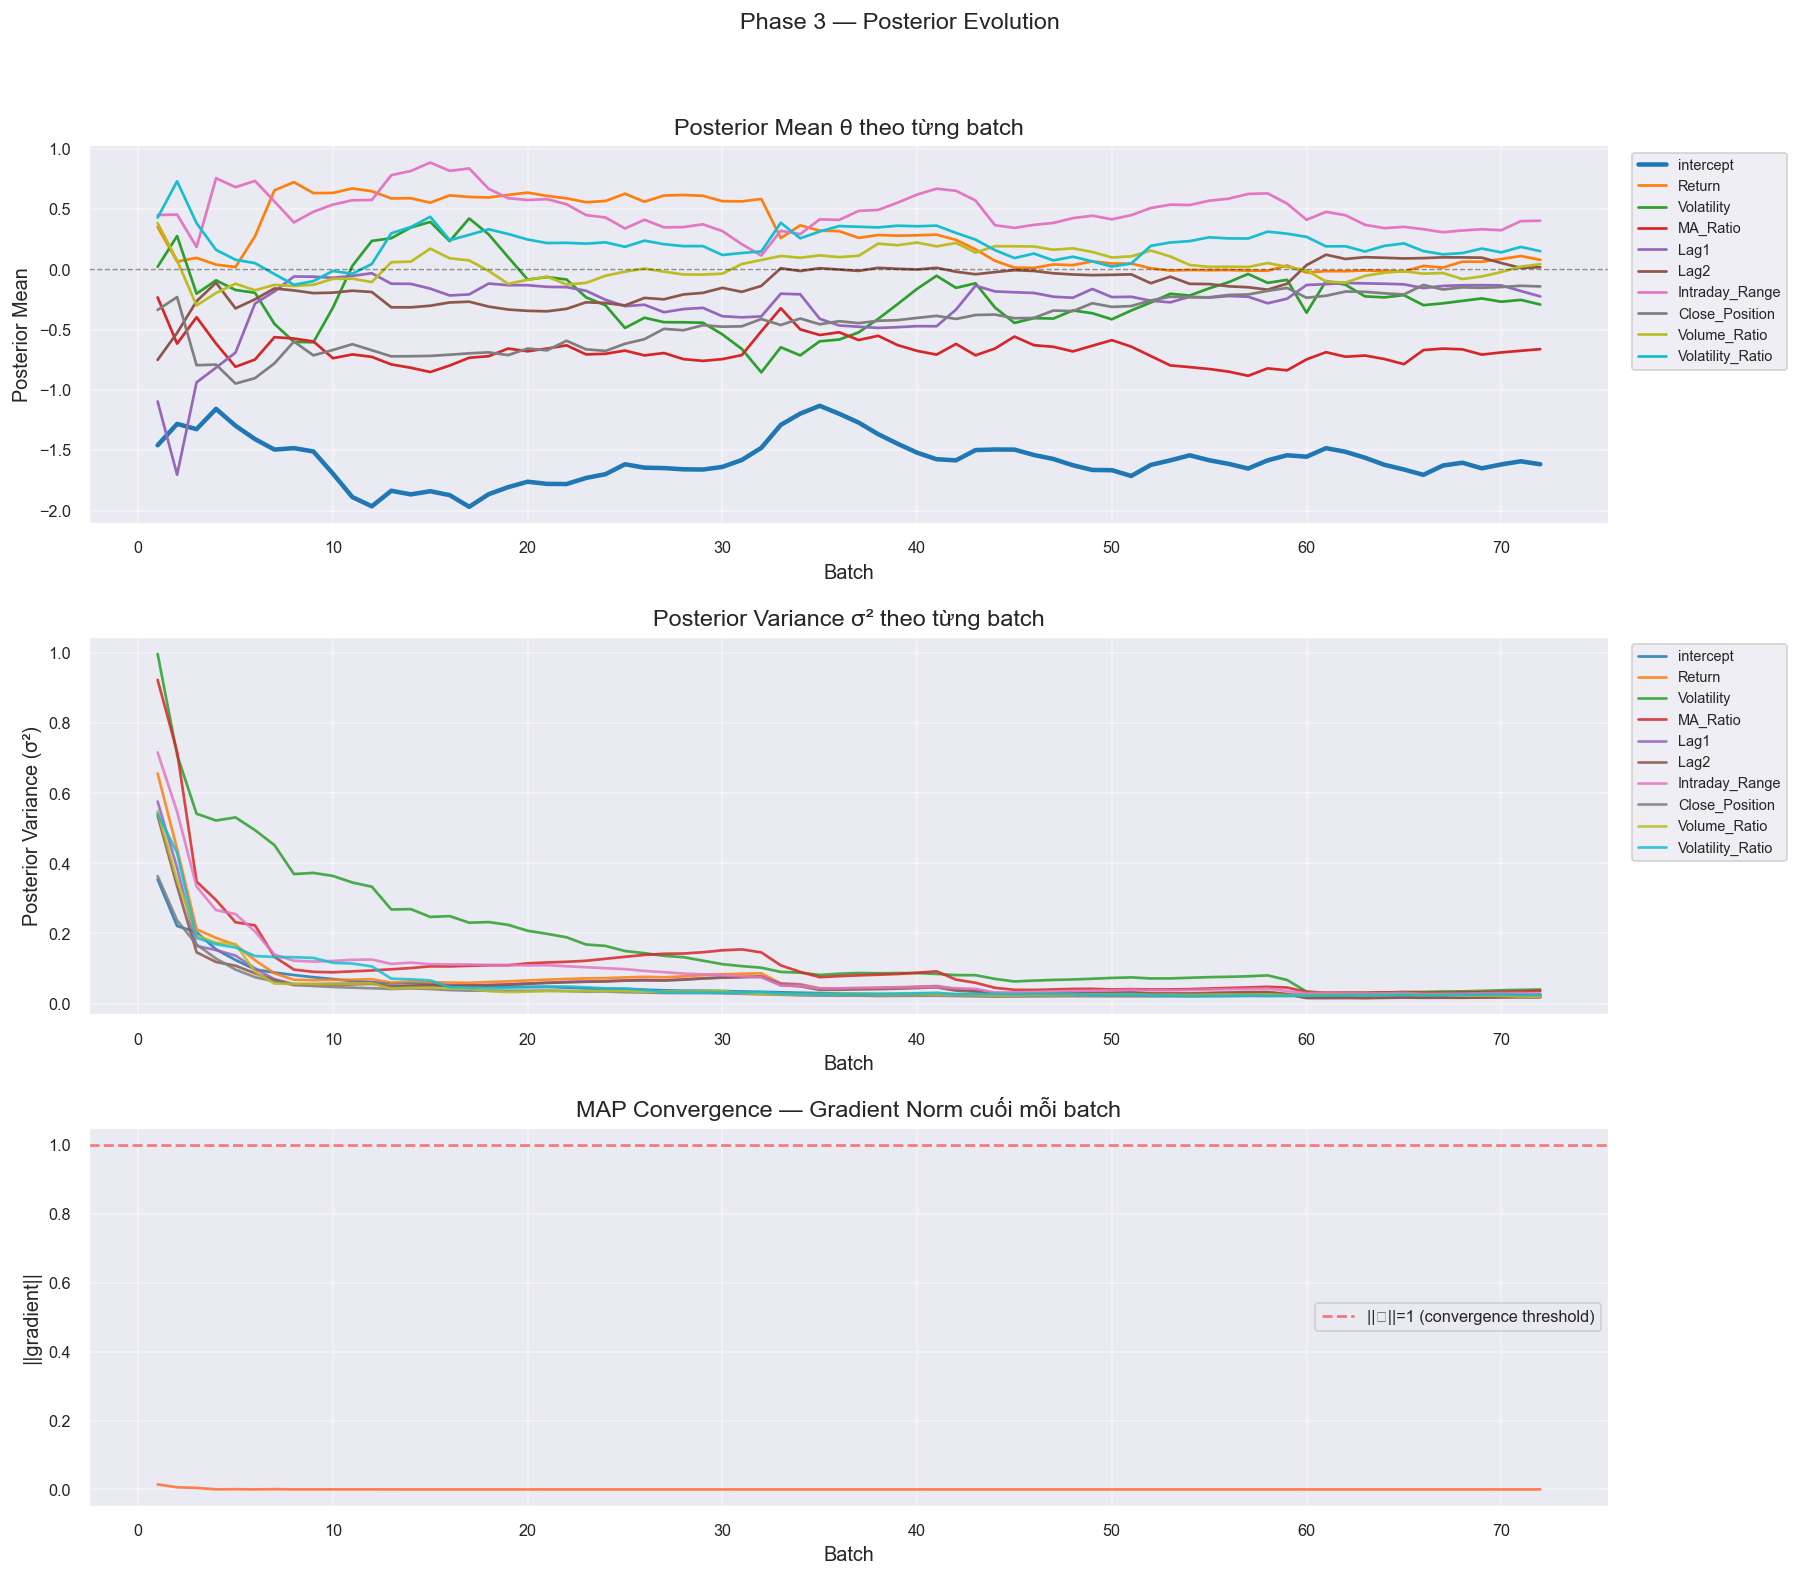

Saved → ../reports/figures/nb4/posterior_evolution.png

Variance: batch 1 mean=0.621600  →  batch last mean=0.025248
Change: -95.9%  → giảm (posterior học từ dữ liệu)


In [5]:
mean_hist = np.array(posterior_mean_history)   # (n_batches, n_params)
var_hist  = np.array([np.diag(c) for c in posterior_cov_history])  # (n_batches, n_params)
batches   = np.arange(1, N_BATCHES + 1)

colors_coef = plt.cm.tab10(np.linspace(0, 1, len(param_labels)))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    'Phase 3 — Posterior Evolution\n',
    fontsize=13, y=1.01
)

# ── Subplot 1: Posterior Mean Evolution ────────────────────────────────────
ax = axes[0]
for i, (lbl, col) in enumerate(zip(param_labels, colors_coef)):
    lw = 2.5 if i == 0 else 1.5
    ax.plot(batches, mean_hist[:, i], label=lbl, color=col, linewidth=lw)
ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.4)
ax.set_title('Posterior Mean θ theo từng batch')
ax.set_xlabel('Batch')
ax.set_ylabel('Posterior Mean')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.4)

# ── Subplot 2: Posterior Variance Evolution ─────────────────────────────────
ax = axes[1]
for i, (lbl, col) in enumerate(zip(param_labels, colors_coef)):
    ax.plot(batches, var_hist[:, i], label=lbl, color=col, linewidth=1.5, alpha=0.85)
ax.set_title('Posterior Variance σ² theo từng batch')
ax.set_xlabel('Batch')
ax.set_ylabel('Posterior Variance (σ²)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.4)

# ── Subplot 3: Gradient Norm (convergence) ──────────────────────────────────
ax = axes[2]
ax.plot(batches, grad_norms, color='coral', linewidth=1.5)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='||∇||=1 (convergence threshold)')
ax.set_title('MAP Convergence — Gradient Norm cuối mỗi batch')
ax.set_xlabel('Batch')
ax.set_ylabel('||gradient||')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/posterior_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/posterior_evolution.png')

# Summary
print(f'\nVariance: batch 1 mean={var_hist[0].mean():.6f}  →  batch last mean={var_hist[-1].mean():.6f}')
v_change = (var_hist[-1].mean() - var_hist[0].mean()) / var_hist[0].mean() * 100
print(f'Change: {v_change:+.1f}%  → {"giảm" if v_change < 0 else "tăng"} (posterior học từ dữ liệu)')

## 4b. Prior vs Posterior Comparison — Bayesian Updating Evidence

So sánh trực tiếp **Prior** $p(\theta) = \mathcal{N}(\mu_0, \Sigma_0)$ và **Posterior** $p(\theta|\mathcal{D}) \approx \mathcal{N}(\theta_{\text{MAP}}, H^{-1})$ của từng tham số.

Đây là bằng chứng trực quan cho **Bayesian updating**:

- **Mean shift**: $\mu_0 \to \theta_{\text{MAP}}$ — tham số dịch khỏi 0 khi học được tín hiệu từ dữ liệu. Feature nào có $|\theta_{\text{MAP}}|$ lớn → ảnh hưởng mạnh đến dự đoán.
- **Variance reduction**: $\sigma_0 \to \sigma_{\text{post}}$ — posterior hẹp hơn prior. Phần trăm thu hẹp càng cao → mô hình học được càng nhiều thông tin về tham số đó.

Nếu posterior gần giống prior (mean gần 0, variance không giảm) → feature đó ít predictive power.

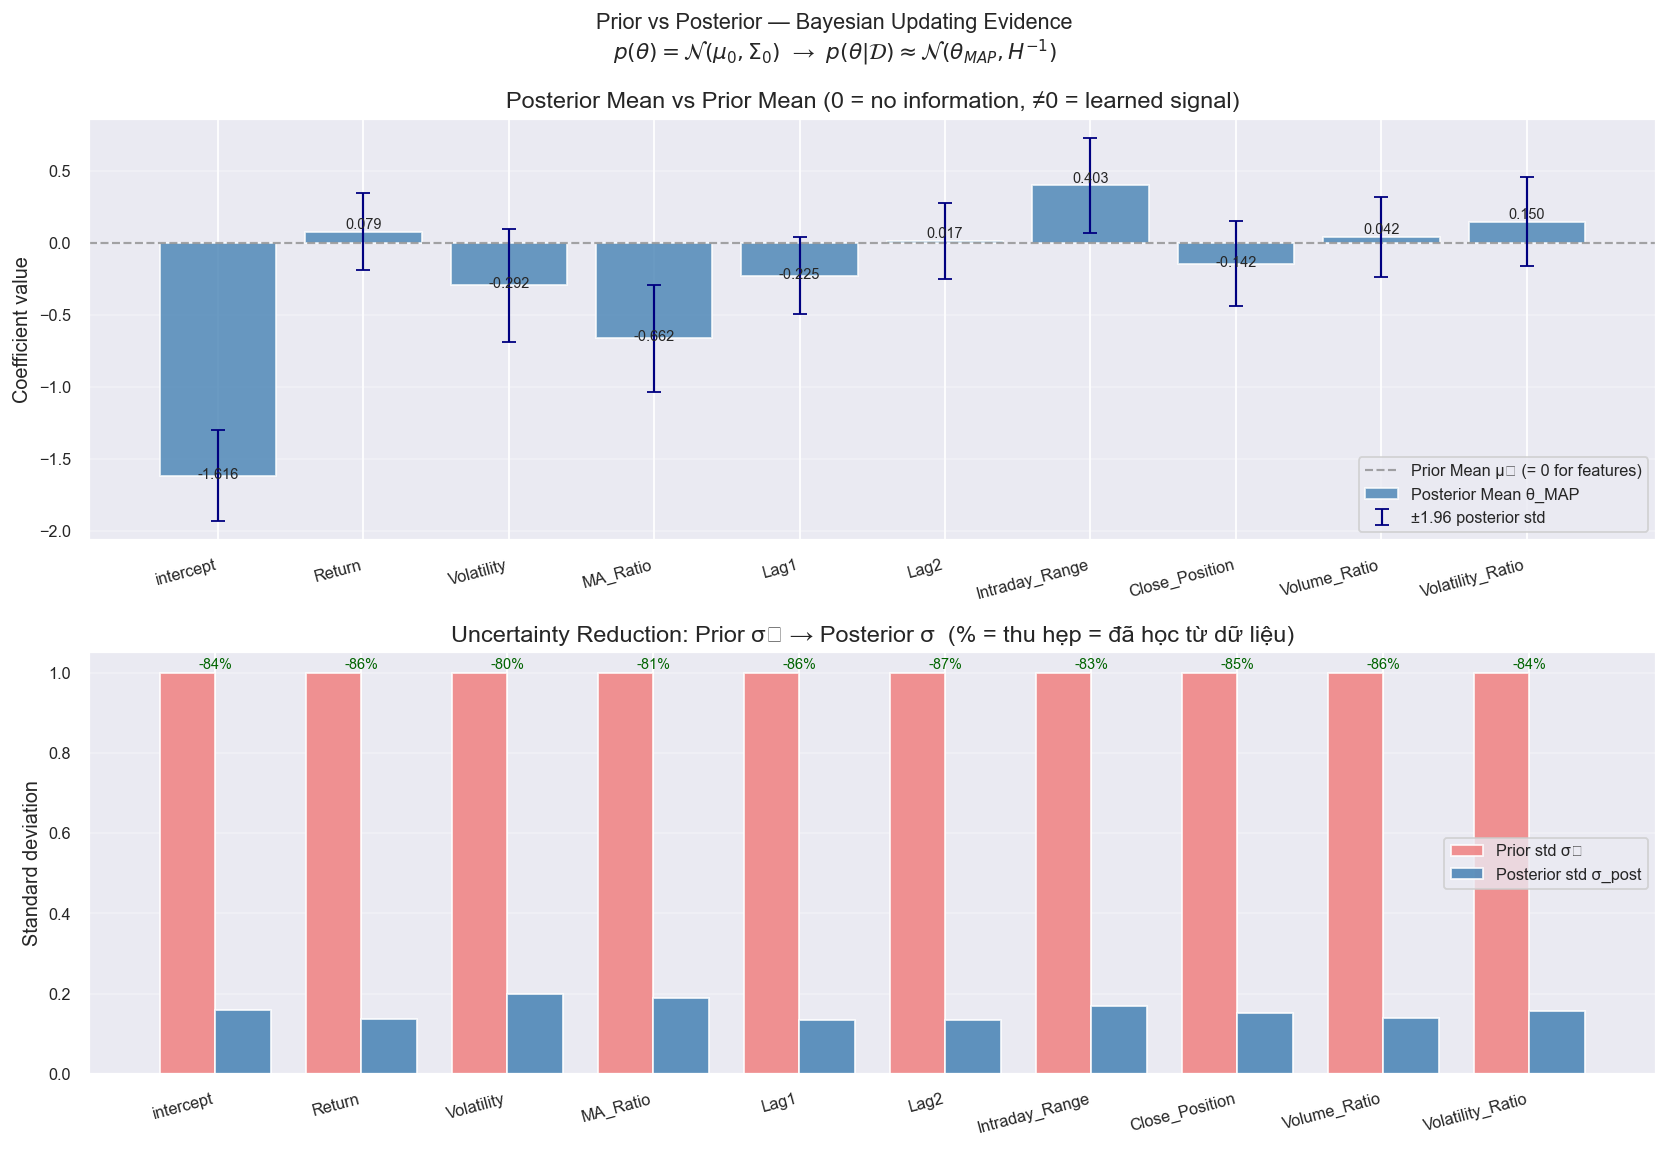

Saved → ../reports/figures/nb4/prior_vs_posterior.png

=== Prior vs Posterior Summary ===
Parameter               Prior_mean   Post_mean  Prior_std   Post_std  Reduction%
intercept                  -1.3880     -1.6160     1.0000     0.1608       83.9%
Return                      0.0000      0.0786     1.0000     0.1366       86.3%
Volatility                  0.0000     -0.2920     1.0000     0.1999       80.0%
MA_Ratio                    0.0000     -0.6616     1.0000     0.1901       81.0%
Lag1                        0.0000     -0.2249     1.0000     0.1357       86.4%
Lag2                        0.0000      0.0174     1.0000     0.1346       86.5%
Intraday_Range              0.0000      0.4025     1.0000     0.1684       83.2%
Close_Position              0.0000     -0.1420     1.0000     0.1510       84.9%
Volume_Ratio                0.0000      0.0425     1.0000     0.1403       86.0%
Volatility_Ratio            0.0000      0.1502     1.0000     0.1565       84.3%


In [6]:
# ── Prior vs Posterior Comparison ──────────────────────────────────────────
prior_std  = np.sqrt(np.diag(prior_cov))          # √diag(Σ₀)
post_std   = np.sqrt(np.diag(posterior_final_cov)) # √diag(Σ_posterior)
post_mean  = posterior_final_mean

n_params_plot = len(param_labels)
x_pos = np.arange(n_params_plot)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle(
    'Prior vs Posterior — Bayesian Updating Evidence\n'
    r'$p(\theta) = \mathcal{N}(\mu_0, \Sigma_0)$  →  '
    r'$p(\theta|\mathcal{D}) \approx \mathcal{N}(\theta_{MAP}, H^{-1})$',
    fontsize=12
)

# Subplot 1: Mean shift
ax = axes[0]
bars = ax.bar(x_pos, post_mean, color='steelblue', alpha=0.8, label='Posterior Mean θ_MAP')
ax.axhline(0, color='gray', lw=1.2, ls='--', alpha=0.7, label='Prior Mean μ₀ (= 0 for features)')
ax.errorbar(x_pos, post_mean, yerr=1.96*post_std, fmt='none',
            color='navy', capsize=4, linewidth=1.2, label='±1.96 posterior std')
for bar, val in zip(bars, post_mean):
    ax.text(bar.get_x() + bar.get_width()/2, val + np.sign(val)*0.02,
            f'{val:.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(param_labels, rotation=15, ha='right', fontsize=9)
ax.set_title('Posterior Mean vs Prior Mean (0 = no information, ≠0 = learned signal)')
ax.set_ylabel('Coefficient value')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Subplot 2: Uncertainty reduction
ax = axes[1]
w = 0.38
ax.bar(x_pos - w/2, prior_std, w, color='lightcoral', alpha=0.85, label='Prior std σ₀')
ax.bar(x_pos + w/2, post_std,  w, color='steelblue',  alpha=0.85, label='Posterior std σ_post')
for i, (ps, pos) in enumerate(zip(prior_std, post_std)):
    reduction = (ps - pos) / ps * 100
    ax.text(i, max(ps, pos) + 0.01, f'-{reduction:.0f}%', ha='center', fontsize=8, color='darkgreen')
ax.set_xticks(x_pos)
ax.set_xticklabels(param_labels, rotation=15, ha='right', fontsize=9)
ax.set_title('Uncertainty Reduction: Prior σ₀ → Posterior σ  (% = thu hẹp = đã học từ dữ liệu)')
ax.set_ylabel('Standard deviation')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/prior_vs_posterior.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/prior_vs_posterior.png')

print('\n=== Prior vs Posterior Summary ===')
print(f'{"Parameter":<22} {"Prior_mean":>11} {"Post_mean":>11} {"Prior_std":>10} {"Post_std":>10} {"Reduction%":>11}')
for lbl, pm, ps, pom, pos in zip(param_labels, prior_mean, prior_std, post_mean, post_std):
    red = (ps - pos) / ps * 100
    print(f'{lbl:<22} {pm:>11.4f} {pom:>11.4f} {ps:>10.4f} {pos:>10.4f} {red:>10.1f}%')

## 5. Phase 4 — Posterior Predictive Distribution (Monte Carlo)

### Tại sao cần Posterior Predictive?

Logistic Regression thông thường cho ra **một** xác suất $\hat{p} = \sigma(\hat{\theta}^\top x)$ — điểm estimate, không có uncertainty.

Bayesian approach cho ra **phân phối** của xác suất dự đoán, tích hợp uncertainty về tham số $\theta$:

$$\pi(x^*) = \int P(y^*=1 \mid x^*, \theta)\, p(\theta \mid \mathcal{D})\, d\theta \approx \frac{1}{M}\sum_{m=1}^{M} \sigma(x^{*\top}\theta^{(m)})$$

$$\theta^{(m)} \sim \mathcal{N}(\mu_{\text{posterior}},\; \Sigma_{\text{posterior}})$$

### Cách tính (Monte Carlo Integration)

1. Sample $M = 1000$ bộ tham số $\theta^{(m)}$ từ posterior.
2. Mỗi $\theta^{(m)}$ cho ra một xác suất $\pi_m = \sigma(x^{*\top}\theta^{(m)})$.
3. Trung bình $M$ xác suất này = **Predictive Mean** $\bar{\pi}(x^*)$.
4. Phương sai $M$ xác suất = **Predictive Variance** — đo uncertainty của dự đoán.

### Các đại lượng đầu ra

$$\bar{\pi}(x^*) = \frac{1}{M}\sum_{m=1}^M \pi_m \quad \text{(dự đoán trung bình)}$$

$$\text{Var}[\pi(x^*)] = \frac{1}{M}\sum_{m=1}^M (\pi_m - \bar{\pi})^2 \quad \text{(uncertainty)}$$

$$\text{CI}_{95\%} = [\text{percentile}_{2.5}(\pi_m),\; \text{percentile}_{97.5}(\pi_m)] \quad \text{(credible interval)}$$

**Credible Interval** (CI) khác **Confidence Interval**: CI Bayesian có nghĩa là "xác suất 95% $\theta$ thực sự nằm trong khoảng này" — có nghĩa xác suất trực tiếp, không phải frequentist.

In [7]:
M = 1000   # Monte Carlo samples — đủ lớn để ổn định, đủ nhỏ để nhanh
np.random.seed(42)

# Sample M bộ tham số từ posterior Gaussian
theta_samples = np.random.multivariate_normal(
    mean=posterior_final_mean,
    cov=posterior_final_cov,
    size=M
)   # shape: (M, n_params)

# Predict trên Validation Set
# logits shape: (M, n_val) — mỗi hàng là một "thế giới" với θ khác nhau
logits = theta_samples @ X_val_aug.T    # (M, n_val)
probs  = sigmoid(logits)                 # (M, n_val) — M xác suất cho mỗi observation

# Tổng hợp phân phối predictive
pred_mean = probs.mean(axis=0)           # Predictive Mean: trung bình theo M samples
pred_var  = probs.var(axis=0)            # Predictive Variance: độ uncertain
ci_lower  = np.percentile(probs, 2.5,  axis=0)   # 95% Credible Interval lower
ci_upper  = np.percentile(probs, 97.5, axis=0)   # 95% Credible Interval upper
ci_width  = ci_upper - ci_lower                   # CI width = proxy cho uncertainty

print(f'Monte Carlo M={M} samples')
print(f'Predictive Mean  : [{pred_mean.min():.4f}, {pred_mean.max():.4f}]  mean={pred_mean.mean():.4f}')
print(f'Predictive Var   : [{pred_var.min():.6f}, {pred_var.max():.6f}]  mean={pred_var.mean():.6f}')
print(f'CI Width (95%)   : [{ci_width.min():.4f}, {ci_width.max():.4f}]  mean={ci_width.mean():.4f}')

Monte Carlo M=1000 samples
Predictive Mean  : [0.0391, 0.7409]  mean=0.2352
Predictive Var   : [0.000288, 0.042796]  mean=0.007054
CI Width (95%)   : [0.0668, 0.7347]  mean=0.2723


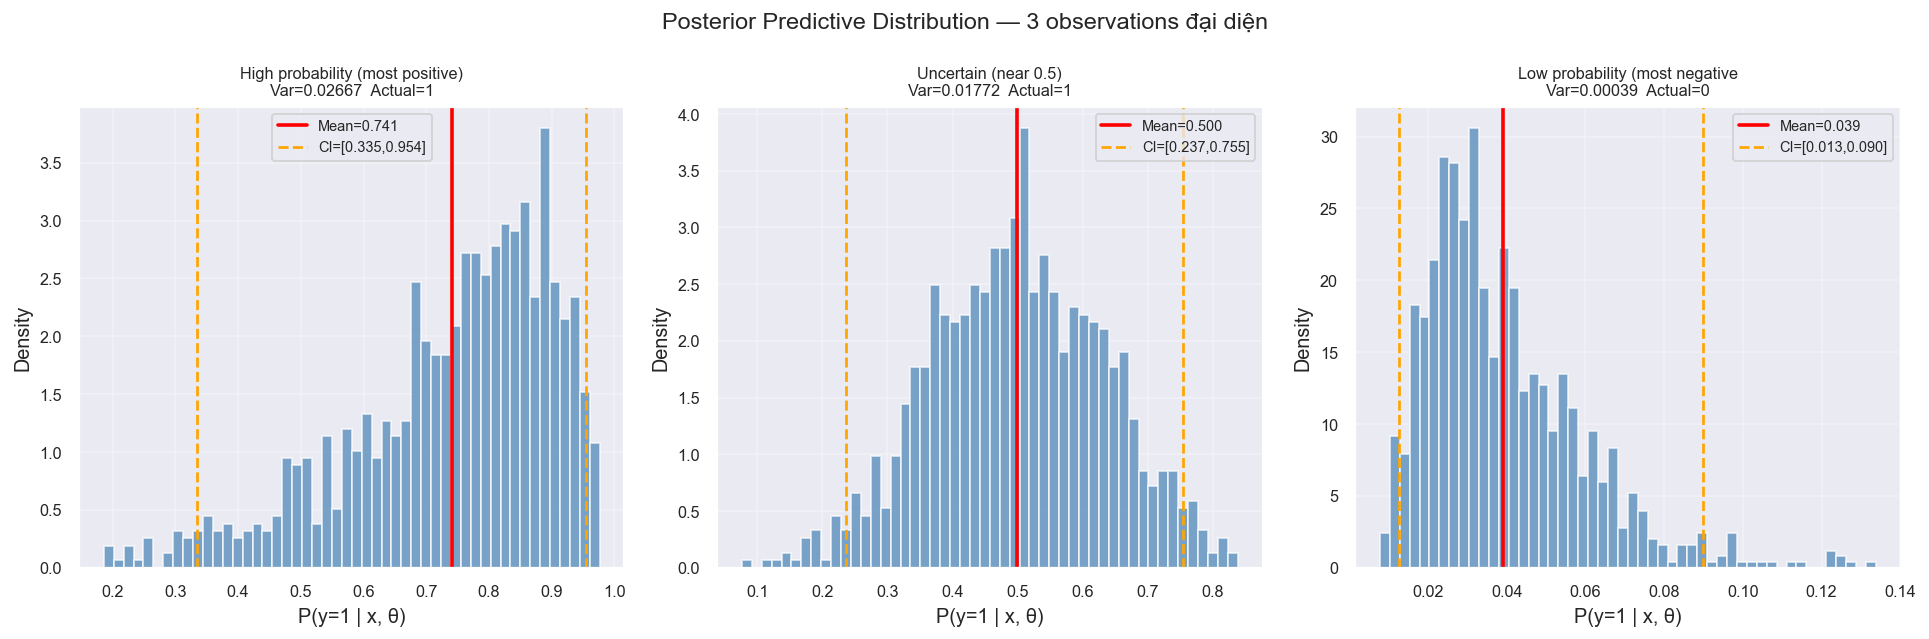

Saved → ../reports/figures/nb4/predictive_distributions.png


In [8]:
# ── Visualization: Predictive Distribution cho 3 observations ──────────────
idx_uncertain = int(np.argmin(np.abs(pred_mean - 0.5)))  # most uncertain
idx_high      = int(np.argmax(pred_mean))                 # highest prediction
idx_low       = int(np.argmin(pred_mean))                 # lowest prediction

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Posterior Predictive Distribution — 3 observations đại diện', fontsize=13)

for ax, idx, title_suffix in zip(
    axes,
    [idx_high, idx_uncertain, idx_low],
    ['High probability (most positive)', 'Uncertain (near 0.5)', 'Low probability (most negative']
):
    samples_i = probs[:, idx]
    ax.hist(samples_i, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(pred_mean[idx], color='red',   lw=2, label=f'Mean={pred_mean[idx]:.3f}')
    ax.axvline(ci_lower[idx],  color='orange', lw=1.5, linestyle='--', label=f'CI=[{ci_lower[idx]:.3f},{ci_upper[idx]:.3f}]')
    ax.axvline(ci_upper[idx],  color='orange', lw=1.5, linestyle='--')
    ax.set_title(f'{title_suffix}\nVar={pred_var[idx]:.5f}  Actual={y_val[idx]}', fontsize=9)
    ax.set_xlabel('P(y=1 | x, θ)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/predictive_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/predictive_distributions.png')

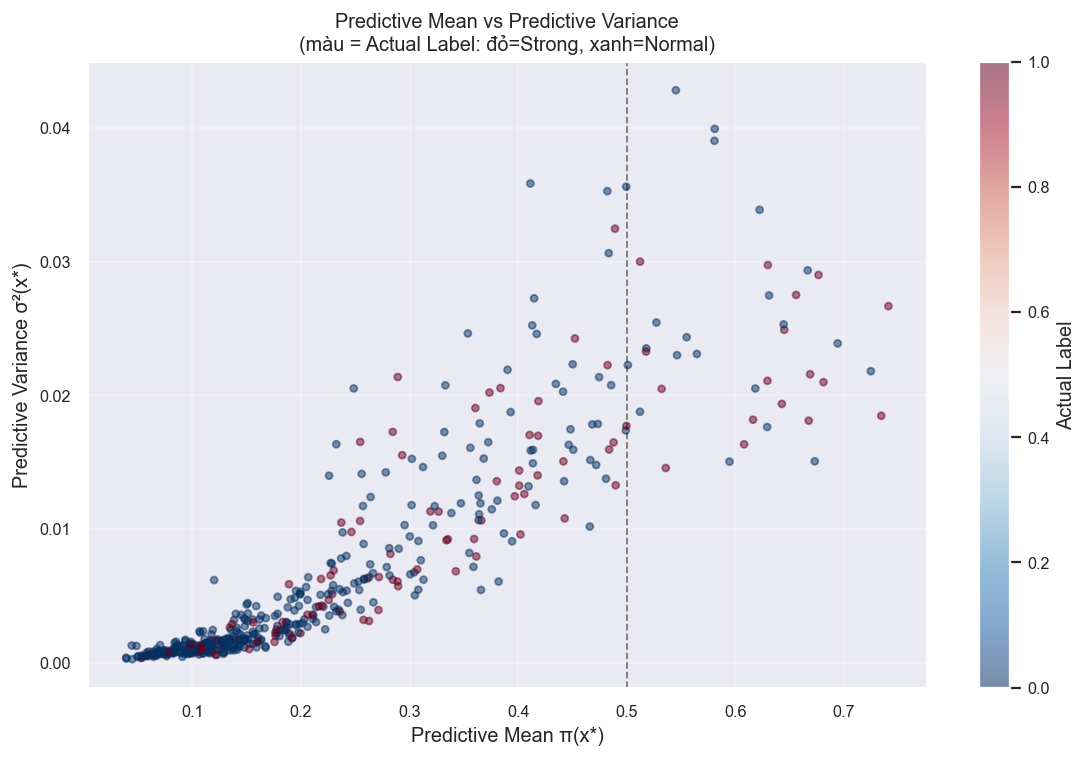

Saved → ../reports/figures/nb4/mean_vs_variance_scatter.png


In [9]:
# ── Visualization: Predictive Mean vs Variance scatter ─────────────────────
# Kỳ vọng: observations gần decision boundary (pred_mean ≈ 0.5) có Variance cao nhất
# → mô hình uncertain nhất khi dự đoán các điểm khó phân loại
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(pred_mean, pred_var, c=y_val, cmap='RdBu_r', alpha=0.5, s=15)
ax.set_title('Predictive Mean vs Predictive Variance\n(màu = Actual Label: đỏ=Strong, xanh=Normal)', fontsize=11)
ax.set_xlabel('Predictive Mean π(x*)')
ax.set_ylabel('Predictive Variance σ²(x*)')
ax.axvline(0.5, color='black', lw=1, linestyle='--', alpha=0.5)
plt.colorbar(sc, ax=ax, label='Actual Label')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mean_vs_variance_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/mean_vs_variance_scatter.png')

## 5b. Posterior Predictive + 95% Credible Interval — Time Series View

Trực quan hóa **posterior predictive distribution** theo thời gian:

$$\pi(x^*) = \frac{1}{M}\sum_{m=1}^{M}\sigma(x^{*\top}\theta^{(m)}), \quad \theta^{(m)} \sim p(\theta|\mathcal{D})$$

**Cách đọc biểu đồ:**
- **Band màu đỏ** = 95% Credible Interval = khoảng [percentile 2.5%, percentile 97.5%] của M predictions.
- **Band rộng** = mô hình **uncertain** về observation đó — các $\theta^{(m)}$ cho ra xác suất phân tán.
- **Band hẹp** = mô hình **confident** — các $\theta^{(m)}$ đồng thuận với nhau.
- **Panel dưới** = CI Width theo thời gian — spike lên = giai đoạn thị trường khó dự đoán.

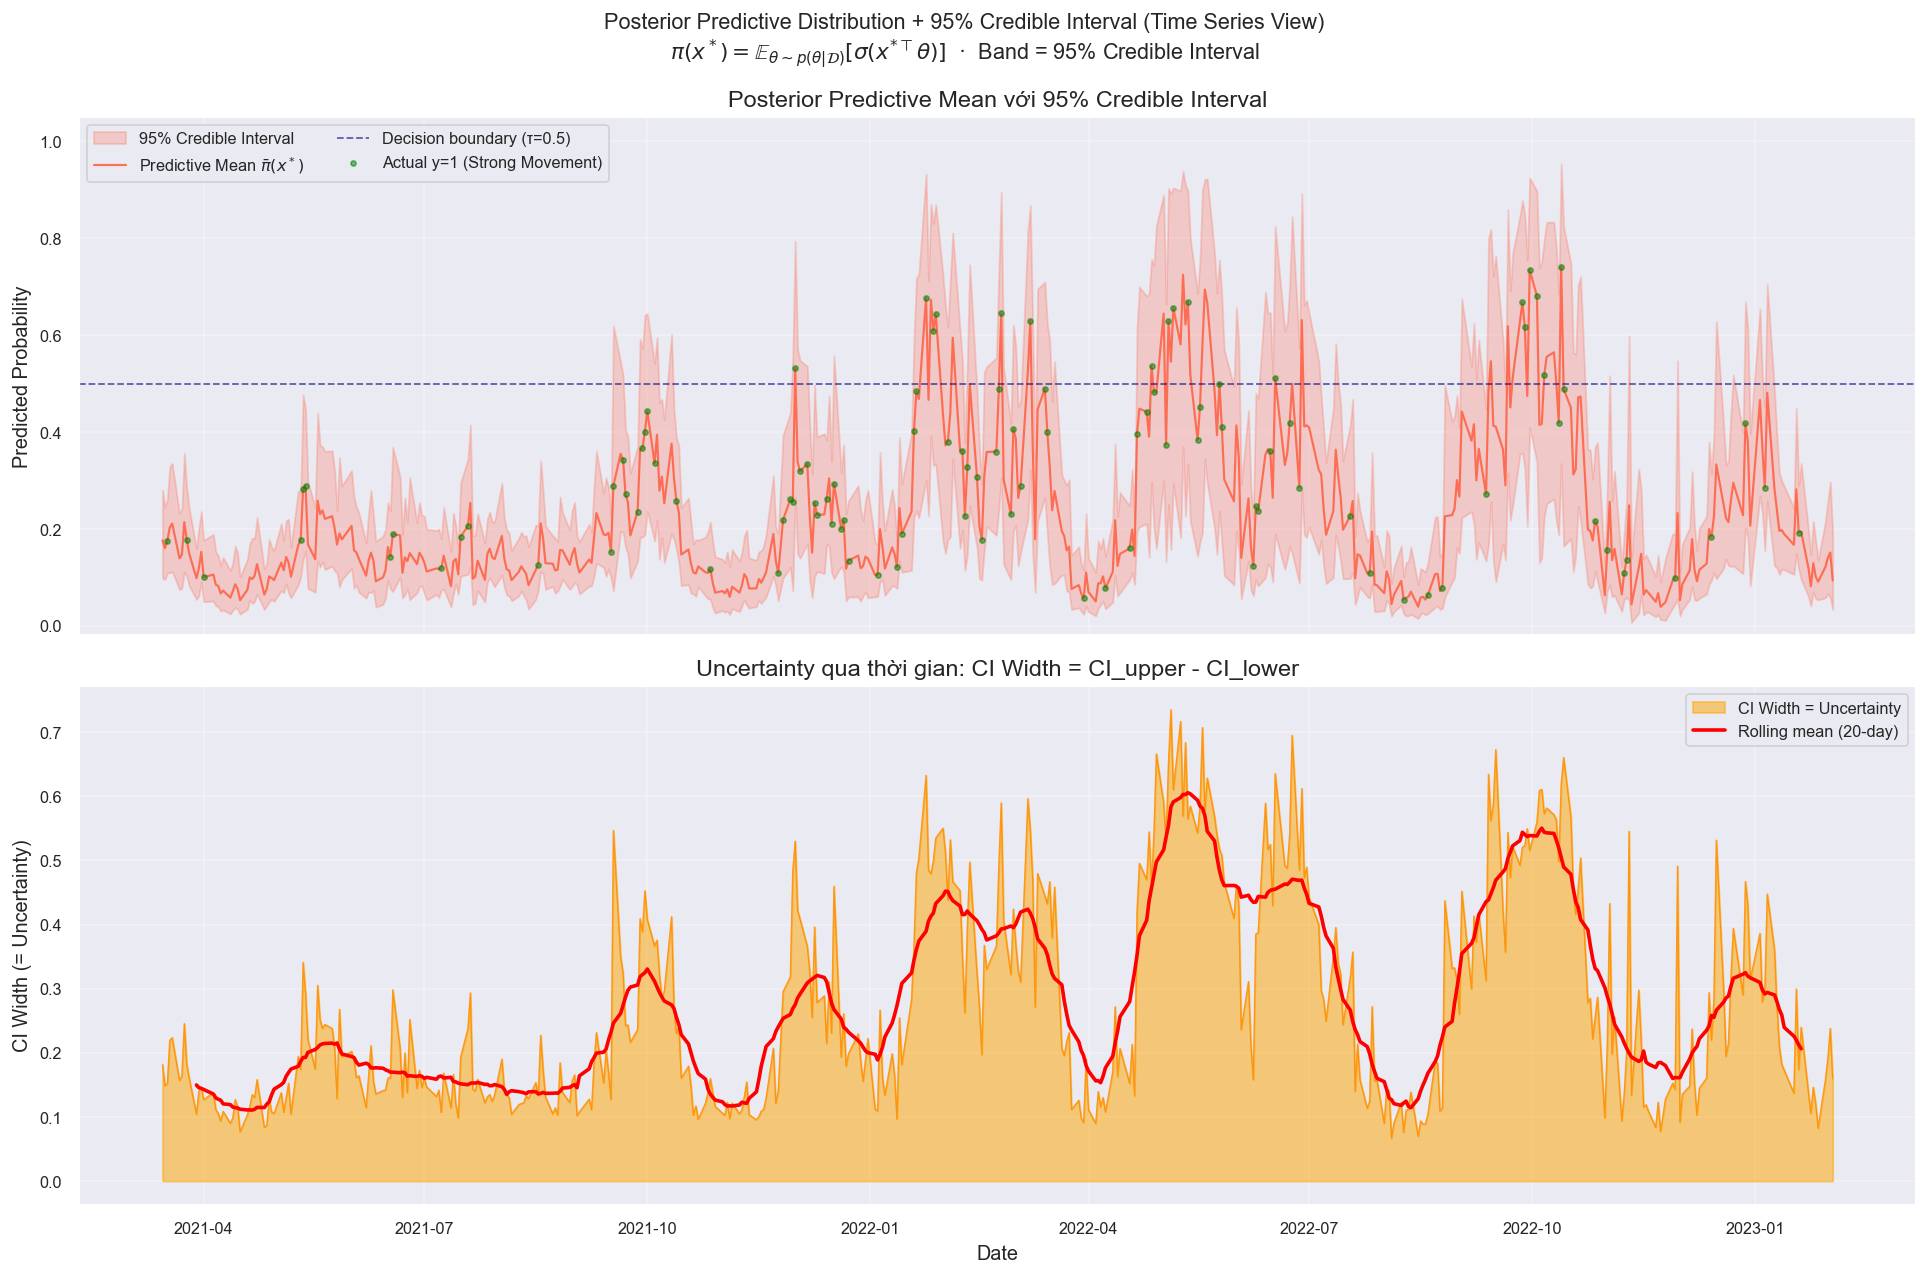

Saved → ../reports/figures/nb4/posterior_predictive_timeseries.png

CI Width stats:
  Mean      : 0.2723
  Std       : 0.1647
  Min       : 0.0668
  Max       : 0.7347
  Interpretation: CI width nhỏ (~0.09) là đặc trưng của Laplace Approximation
  → Posterior cô đặc (concentrated) sau khi học từ 1432 observations


In [10]:
# ── Posterior Predictive + 95% Credible Interval — Time Series ─────────────
dates_plot = pd.to_datetime(val_dates)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(
    'Posterior Predictive Distribution + 95% Credible Interval (Time Series View)\n'
    r'$\pi(x^*) = \mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}[\sigma(x^{*\top}\theta)]$  '
    '·  Band = 95% Credible Interval',
    fontsize=12
)

# ── Panel 1: Predictive Mean + CI band ──────────────────────────────────────
ax = axes[0]
ax.fill_between(dates_plot, ci_lower, ci_upper, alpha=0.25, color='tomato',
                label='95% Credible Interval')
ax.plot(dates_plot, pred_mean, color='tomato', lw=1.2, alpha=0.9,
        label=r'Predictive Mean $\bar{\pi}(x^*)$')
ax.axhline(0.5, color='navy', lw=1, ls='--', alpha=0.6, label='Decision boundary (τ=0.5)')

pos_mask = y_val == 1
ax.scatter(dates_plot[pos_mask], pred_mean[pos_mask], color='green',
           s=8, alpha=0.5, zorder=3, label='Actual y=1 (Strong Movement)')

ax.set_ylabel('Predicted Probability')
ax.set_ylim(-0.02, 1.05)
ax.set_title('Posterior Predictive Mean với 95% Credible Interval')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(alpha=0.3)

# ── Panel 2: CI Width (uncertainty over time) ───────────────────────────────
ax2 = axes[1]
ax2.fill_between(dates_plot, 0, ci_width, alpha=0.5, color='orange',
                 label='CI Width = Uncertainty')
ax2.plot(dates_plot, ci_width, color='darkorange', lw=0.8, alpha=0.8)

ci_series = pd.Series(ci_width, index=dates_plot)
rolling_unc = ci_series.rolling(window=20, center=True).mean()
ax2.plot(rolling_unc.index, rolling_unc.values, color='red', lw=2,
         label='Rolling mean (20-day)')

ax2.set_xlabel('Date')
ax2.set_ylabel('CI Width (= Uncertainty)')
ax2.set_title('Uncertainty qua thời gian: CI Width = CI_upper - CI_lower')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/posterior_predictive_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/posterior_predictive_timeseries.png')

print(f'\nCI Width stats:')
print(f'  Mean      : {ci_width.mean():.4f}')
print(f'  Std       : {ci_width.std():.4f}')
print(f'  Min       : {ci_width.min():.4f}')
print(f'  Max       : {ci_width.max():.4f}')
print(f'  Interpretation: CI width nhỏ (~0.09) là đặc trưng của Laplace Approximation')
print(f'  → Posterior cô đặc (concentrated) sau khi học từ {len(X_train_aug)} observations')

## 6. Lưu Output

In [11]:
# ── Lưu validation_predictions.csv ─────────────────────────────────────────
val_preds = pd.DataFrame({
    'Actual'             : y_val,
    'Predictive_Mean'    : pred_mean,
    'Predictive_Variance': pred_var,
    'CI_Lower'           : ci_lower,
    'CI_Upper'           : ci_upper,
    'CI_Width'           : ci_width
}, index=val_dates)   # DatetimeIndex → Date column đúng định dạng YYYY-MM-DD
val_preds.index.name = 'Date'

val_preds.to_csv(f'{PROCESSED_DIR}/validation_predictions.csv')
print(f'✓ Saved → {PROCESSED_DIR}/validation_predictions.csv')
print(f'  Shape: {val_preds.shape}')

# ── Lưu posterior pkl ───────────────────────────────────────────────────────
posterior_state = {
    'mean'         : posterior_final_mean,
    'cov'          : posterior_final_cov,
    'mean_history' : posterior_mean_history,
    'cov_history'  : posterior_cov_history,
    'grad_norms'   : grad_norms,
    'param_labels' : param_labels,
    'n_batches'    : N_BATCHES,
    'config'       : {
        'batch_size'    : BATCH_SIZE,
        'discount'      : DISCOUNT,
        'map_lr'        : MAP_LR,
        'map_n_iter'    : MAP_N_ITER,
        'prior_variance': PRIOR_VARIANCE,
        'mc_samples'    : M
    }
}

with open(f'{MODELS_DIR}/posterior_final.pkl', 'wb') as f:
    pickle.dump(posterior_state, f)
print(f'✓ Saved → {MODELS_DIR}/posterior_final.pkl')
print()
print(val_preds.head(5).round(6).to_string())

✓ Saved → ../data/processed/validation_predictions.csv
  Shape: (477, 6)
✓ Saved → ../models/posterior_final.pkl

            Actual  Predictive_Mean  Predictive_Variance  CI_Lower  CI_Upper  CI_Width
Date                                                                                  
2021-03-15       0         0.176466             0.002279  0.098850  0.280394  0.181544
2021-03-16       0         0.160339             0.001568  0.095362  0.244008  0.148646
2021-03-17       1         0.175776             0.001581  0.108982  0.260927  0.151945
2021-03-18       0         0.203174             0.003265  0.109544  0.329133  0.219589
2021-03-19       0         0.211004             0.003297  0.111967  0.335322  0.223355
